In [22]:
import matplotlib.pyplot as plt
import numpy as np

from block_encoding import generate_laplacian_block_encoding, get_circuit_unitary
from camps_be import camps_block_encoding

In [2]:
def v1_vec(nq):
    x = np.arange(2**nq) / 2**nq

    return np.sin(2 * np.pi * x)

def v2_vec(nq):
    x = np.arange(2**nq) / 2**nq

    return np.sin(6 * np.pi * x)

def actual_laplacian(v_vec):
    h = 1 / len(v_vec)

    vals = []

    for i in range(len(v_vec)):
        up = (i+1) % len(v_vec)
        down = i - 1

        if down < 0:
            vals.append(v_vec[up] - 2 * v_vec[i])

        elif up == len(v_vec):
            vals.append(-2 * v_vec[i] + v_vec[down])

        else:
            vals.append(v_vec[up] - 2 * v_vec[i] + v_vec[down])

    return np.array(vals) / h**2

/var/folders/tn/vkkzwdwn1cs5s6w9wqnpcz3c0000gn/T/ipykernel_29763/2880912477.py:43: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(deltas, camps_v1_success, "o", marker="v", color="green", label="$v_1$, Camps et al.")
/var/folders/tn/vkkzwdwn1cs5s6w9wqnpcz3c0000gn/T/ipykernel_29763/2880912477.py:44: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(deltas, camps_v2_success, "o", marker="v", color="blue", label="$v_2$, Camps et al.")


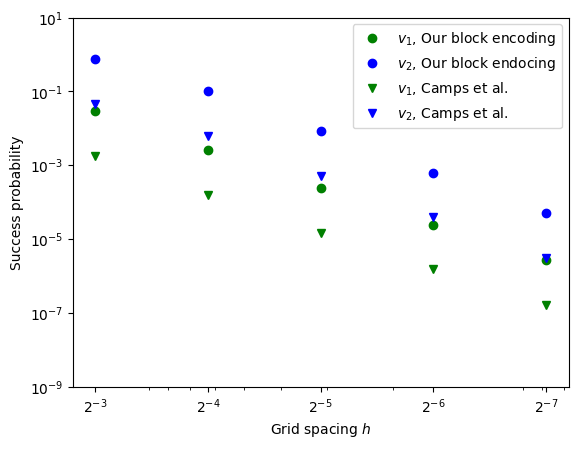

In [19]:
nqs = list([i] for i in range(3, 8))
deltas = list([2**(-nq) for nq in nqs[i]] for i in range(len(nqs)))
prob_success_v1_be1 = []
prob_success_v2_be1 = []

camps_v1_success = []
camps_v2_success = []

for i in range(len(nqs)):
    v = v1_vec(nqs[i][0])
    v_normed = v / np.linalg.norm(v)

    # My code
    qc = generate_laplacian_block_encoding(nqs[i], deltas=deltas[i], vs=v_normed)
    unitary = get_circuit_unitary(qc, nqs[i])
    prob_success_v1_be1.append(np.linalg.norm(unitary[:, 0]) ** 2)

    # Camps
    qc = camps_block_encoding(nqs[i][0], ["dirichlet"], vs=v_normed)
    unitary = get_circuit_unitary(qc, nqs[i])
    camps_v1_success.append(np.linalg.norm(unitary[:, 0]) ** 2)


    v = v2_vec(nqs[i][0])
    v_normed = v / np.linalg.norm(v)

    # My code
    qc = generate_laplacian_block_encoding(nqs[i], deltas=deltas[i], vs=v_normed)
    unitary = get_circuit_unitary(qc, nqs[i])
    prob_success_v2_be1.append(np.linalg.norm(unitary[:, 0]) ** 2)

    # Camps
    qc = camps_block_encoding(nqs[i][0], ["dirichlet"], vs=v_normed)
    unitary = get_circuit_unitary(qc, nqs[i])
    camps_v2_success.append(np.linalg.norm(unitary[:, 0]) ** 2)
    

qc.decompose().draw(output="mpl")


plt.plot(deltas, prob_success_v1_be1, "o", color="green", label="$v_1$, Our block encoding")
plt.plot(deltas, prob_success_v2_be1, "o", color="blue", label="$v_2$, Our block endocing")
plt.plot(deltas, camps_v1_success, "o", marker="v", color="green", label="$v_1$, Camps et al.")
plt.plot(deltas, camps_v2_success, "o", marker="v", color="blue", label="$v_2$, Camps et al.")
plt.xscale("log")
plt.yscale("log")
plt.gca().invert_xaxis()
plt.xticks([2**-i for i in range(3, 8)])
plt.yticks([10**i for i in range(-9, 2, 2)])
plt.gca().set_xticklabels([f"$2^{{-{i}}}$" for i in range(3, 8)])
plt.xlabel("Grid spacing $h$")
plt.ylabel("Success probability")
plt.legend()
plt.show()